#**Κώδικες υπολογιστικής φυσικής**
Το παρόν προορίζεται να γίνει ένα "διαδραστικό βοήθημα", δηλαδή ο φοιτητής θα μπορεί, ακολουθώντας το, να εξασκηθεί σε όλη την έκταση της ύλης της Υπολογιστικής Φυσικής.
**Δεν** αντικαθιστά την ανάγνωση σημειώσεων ή συγγραμμάτων για εμπέδωση της θεωρίας. Θα γίνει προσπάθεια να **υπενθυμίζεται** η κάθε μέθοδος πριν χρησιμοποιηθεί.

## **0. Εισαγωγικά (εντολές της Python)**

In [2]:
print('Hello!')         #Με την εντολή print τυπώνουμε κάτι. Σε '' βάζουμε το απλό κείμενο που θέλουμε να τυπώσουμε
x=3                     #Η μεταβλητή x ορίστηκε με τιμή 3. Αυτή η τιμή μπορεί να αλλάξει αργότερα, πχ:
x=x+2                   #Λίγο περίεργο όταν το πρωτοκοιτάζει κανείς, σημαίνει 'όπου είχες x βάλε x+2'
print(x)                #Οι μεταβλητές τυπώνονται χωρίς ''. Θα μπορούσαμε αντί για print(x) να γράφαμε και απλώς x
y=5
if x>y:                 #Συνθήκη
  print(x, 'is larger') #Εντολή (εκτελείται μόνο αν ικανοποιείται η συνθήκη)
elif x==y:              #Όταν περιγράφουμε συνθήκες (μέσα σε if, for...) αντί για = βάζουμε ==
  print(x, 'is equal to', y)
else:                   #Else= σε κάθε άλλη περίπτωση
  print(y, 'is larger')

Hello!
5
5 is equal to 5


Ας μάθουμε να σχεδιάζουμε συναρτήσεις. Το συγκεκριμένο αποτελεί και το ερώτημα α της άσκησης 1 στην εργασία 2 της Μηχανικής Ι (ακαδ. έτος 2024-25)

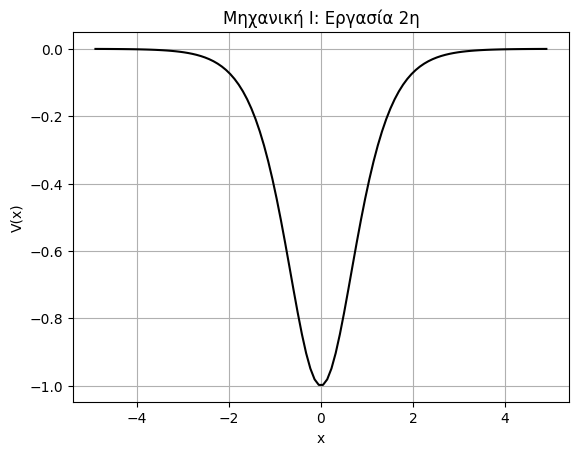

In [3]:
import numpy as np              #import (το όνομα του πακέτου) as (πώς θα το ονομάσουμε εμείς για να μη γράφουμε συνέχεια)
#Η numpy είναι ένα πολύ βασικό πακέτο που δε χάνουμε κάτι να εγκαθιστούμε σε κάθε πρόγραμμα
import matplotlib. pyplot as plt#Αυτή δανείζεται κομμάτια κώδικα μίας άλλης γλώσσας, της MatLab, για να σχεδιάσει γραφήματα κ.α.

N = 108
x = np.linspace(-4.9, 4.9, N)  #N ισαπέχοντα στοιχεία στο διάστημα -4.9 έως 4.9
y = -1 / (np.cosh(x))**2  # Η συνάρτησή μας

plt.figure()
plt.plot(x, y, color='black')
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Μηχανική Ι: Εργασία 2η')
plt.grid()
plt.show()

Τα for loops επιτρέπουν την εκτέλεση της ίδιας διαδικασίας πολλές φορές χωρίς να γράφουμε κάθε φορά τον ίδιο κώδικα, π.χ. για να σχεδιάζουμε την ίδια συνάρτηση για διαφορετικές τιμές των ελευθέρων παραμέτων:

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4780/1043133289.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.title(' $V_{eff}(r)$ για διάφορες τιμές της στροφορμής $\mathcal{L}$', fontfamily='serif')#\mathcal{} για καλλιγραφικά, πειραματιστείτε με το serif, sans,...


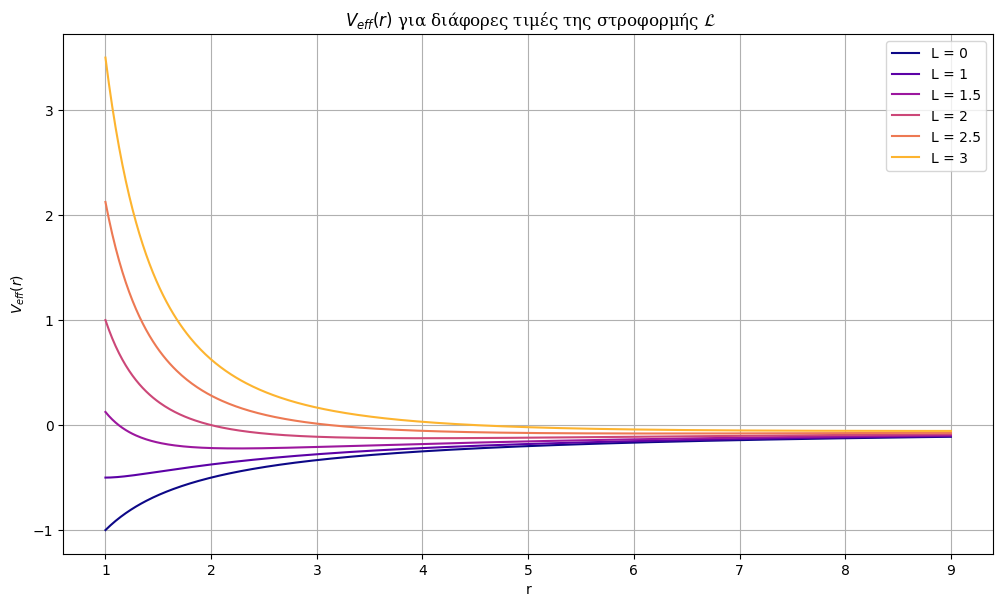

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def V(r, L):
  return -1/r + L**2/(2*r**2)

L_values = [0, 1, 1.5, 2, 2.5, 3]#Δοκιμάστε και άλλες αν θέλετε!

r = np.linspace(1, 9, 500)
plt.figure(figsize=(12, 9*3/4))

cmap = plt.cm.plasma             #Για να μην ψάχνουμε συνέχεια χρώματα, επιλέγουμε μία χρωματική παλέττα και η Pyhton κάνει τα υπόλοιπα.
                                 #Η συγκεκριμένη είναι δημοφιλής στην αστροφυσική.
for i, L in enumerate(L_values):
    plt.plot(r, V(r, L), label=f'L = {L}', color=cmap(i / len(L_values)))

plt.xlabel('r')
plt.ylabel('$V_{eff}(r)$')
plt.title(' $V_{eff}(r)$ για διάφορες τιμές της στροφορμής $\mathcal{L}$', fontfamily='serif')#\mathcal{} για καλλιγραφικά, πειραματιστείτε με το serif, sans,...
plt.grid(True)
plt.legend()
plt.show()

Η αναπαράσταση συναρτήσεων δύο μεταβλητών είναι ίσως η αγαπημένη μου διαδικασία στην python, επειδή είναι σχεδόν αδύνατο χειρόγραφα. Εδώ θα οπτικοποιήσουμε τον λόγο για τον οποίο η διάδοση σφάλματος δίνεται από τη σχέση
$$δf(x,y)=\sqrt{\left(\frac{\partial f(x,y)}{\partial x}\Bigg|_{(x_0, y_0)}δx\right)^2+\left(\frac{\partial f(x,y)}{\partial y}\Bigg|_{(x_0, y_0)}δy\right)^2}$$

Για περισσότερες παραμέτρους η οπτικοποίηση είναι πολύ δυσκολότερη, αλλά η ουσία είναι ίδια!

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4780/955529529.py:31: SyntaxWarning: invalid escape sequence '\p'
  ax.quiver(x[69], y[69],f(x[69], y[69]) , delta_x, 0, df_dx*delta_x, color='blue', label='$\partial f/ \partial x$', length=0.35)
/tmp/ipykernel_4780/955529529.py:32: SyntaxWarning: invalid escape sequence '\p'
  ax.quiver(x[69], y[69], f(x[69], y[69]), 0, delta_y, df_dy*delta_y, color='green', label='$\partial f/\partial y$', length=0.35)


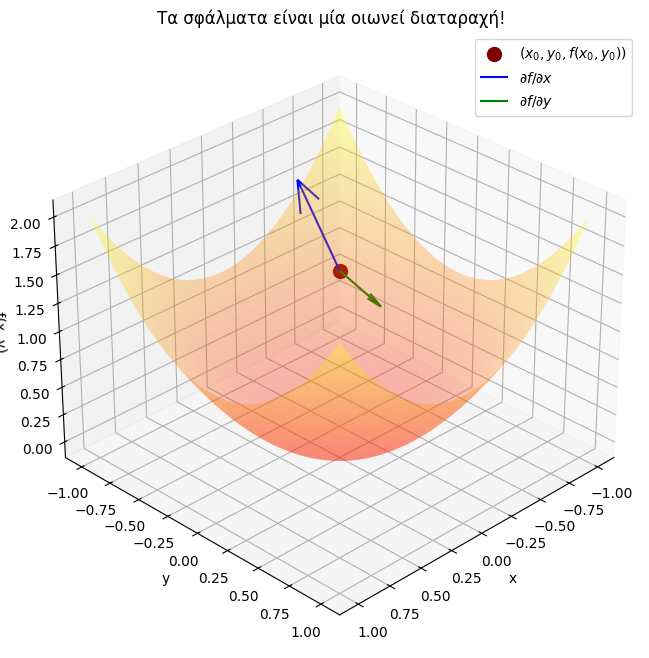

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x, y):
    f= x**2 + y**2; return f #Όποια συνάρτηση θέλουμε!

# Μερικές παράγωγοι (υπολογίζονται αναλυτικά & έπειτα εφαρμόζονται στο επιθυμητό σημείο)
df_dx = 2 * x[69]
df_dy = 2 * y[69]

# "Διαταραχές" στα x και y
delta_x = 1
delta_y = 1

#Το "υπόβαθρο" του ϖλοτ
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Το ϖλοτ
x = np.linspace(-1, 1, 400)
y = np.linspace(-1, 1, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)
ax.plot_surface(X, Y, Z, alpha=0.31, cmap='autumn')

# Το επιθυμητό σημείο
ax.scatter([x[69]], [y[69]], [f(x[69], y[69])], c='maroon', marker='o', s=100, label=f'($x_0, y_0, f(x_0, y_0)$)')

# Τα βέλη (μερικές παράγωγοι)
ax.quiver(x[69], y[69],f(x[69], y[69]) , delta_x, 0, df_dx*delta_x, color='blue', label='$\partial f/ \partial x$', length=0.35)
ax.quiver(x[69], y[69], f(x[69], y[69]), 0, delta_y, df_dy*delta_y, color='green', label='$\partial f/\partial y$', length=0.35)

# Όπως νωρίτερα, ονομάζουμε άξονες και βάζουμε τίτλο
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Τα σφάλματα είναι μία οιωνεί διαταραχή!')

# Υπόμνημα
ax.legend()

# Κλίση
ax.view_init(elev=30, azim=45)

plt.show()
#Η εντολή \partial, με την οποία έβαλα τις μερικές παραγώγους, δουλεύει αλλά εμφανίζει μερικές προειδοποιήσεις. Αγνοήστε τις (αν ξέρετε καλύτερο τρόπο ενημερώστε με).

Ας μάθουμε να υπολογίζουμε αριθμητικά άπειρες σειρές: θα υπολογίσουμε τον αριθμό $\pi$ μέσω του τύπου του $\text{Ramanujan}$!
Ο τύπος είναι:
$$\frac{1}{\pi} = \frac{2\sqrt{2}}{9801} \sum_{n=0}^{\infty} \frac{(4n)!}{(n!)^4} \frac{(1103 + 26390n)}{396^{4n}}$$
Δε χρειάζεται να υπολογίσουμε πολλούς όρους της σειράς, αφού ακόμα και για $n=0$ είναι μία εντυπωσιακά καλή προσέγγιση. Θα το κάνουμε όμως με τη γενική μορφή.

In [6]:
### Σταθερό σημείο (fixed point) ###
import math
def R(n): R=1/(9801*((math.factorial(n))**4)*(396**(4*n))/((math.factorial(4*int(n)))*(2*math.sqrt(2))*(1103+26390*n))); return R#Προσοχή στο int!
N=2             #Υπέρ αρκετό
S=0
for i in range (0,N):
  S+=R(i)
pi=1/S
print(pi)

3.1415926535897936


## **1. Μέση τιμή, διασπορά...**

Εύρεση της μέσης τιμής ισοπίθανων ενδεχομένων: $$\mu=\frac{\sum_{i=1}^N x_i}{\sum_{i=1}^N i}\equiv\frac{\sum_{i=1}^N x_i}{N}$$

Ένας αλγόρθμος υπολογισμού του $\mu$, δηλαδή, θα πρέπει να έχει την εξής δομή:
*   Διάβασε τον πίνακα $x$.
*   $N=$ πλήθος στοιχείων του $x$. $\mu=0$.
*   Για κάθε τιμή του $i$ από το 0 έως το $N-1$ *(προσοχή! σχεδόν κάθε γλώσσα προγραμματισμού χρησιμοποιεί την αρίθμηση 0,1,2,...)* κάνε τα εξής:
    1. $\mu+=x_i/N$.
*   Τύπωσε $\mu$.

Πάμε να το εφαρμόσουμε στην python:

In [7]:
#Ας δημιουργήσουμε έναν πίνακα με τα δεδομένα, των οποίων τη μέση τιμή θέλουμε να βρούμε.
#Π.χ. οι βαθμοί μου στο Α' εξάμηνο:
A=[7,4,5,3,9]
#Ο "χειροκίνητος" (και πλέον διαισθητικός) τρόπος να υπολογίσουμε το μ είναι
μ=0     #Αρχικοποίηση!
for i in range(len(A)):
  μ+=A[i]/len(A)
print(μ)#Εναλλακτικά, θα μπορούσαμε φυσικά να προσθέτουμε κάθε φορά A[i] και στο τέλος να έχουμε μία εντολή μ/=len(A)

#Για να μη γεμίζουμε αχρείαστα (και ανύπαρκτα, βλ. π.χ. διαφάνειες Δασύρα, Υ2) δεκαδικά, μπορούμε να γράφουμε print(round(μ,2)) (στρογγυλοποίηση του μ σε 2 δεκαδικούς)

5.6000000000000005


Όταν τα δεδομένα μας χαρακτηρίζονται από συντελεστές (όπως π.χ. η συνεισφορά των μαθημάτων στο ΜΟ), σε κάθε $x_i$ αντιστοιχεί και ένας συντελεστής $s_i$. Η μέση τιμή τροποποιείται ως $$\mu=\frac{\sum_{i=1}^N s_ix_i}{\sum_{i=1}^N s_i}$$

Ειδική περίπτωση του παραπάνω (για $\sum_i s_i=1$) αποτελεί η εύρεση μέσης τιμής όταν τα διάφορα ενδεχόμενα δεν είναι ισοπίθανα!

In [8]:
A=[7,4,5,3,9]
S=[2,2,1.5,1.5,1]
μ=0; Sums=0
for i in range(len(A)):
  μ+=A[i]*S[i]
  Sums+=S[i]
μ/=Sums
print(μ)

5.375


Για τη διασπορά ενός μεγέθους εξυπηρετεί συνήθως η έκφραση
$$\sigma^2=\frac{\sum_{i=1}^N\left(x_i-\mu\right)^2}{N}$$

όπου περιοριστήκαμε χάρην απλότητας στην περίπτωση που δεν υπάρχουν συντελεστές. Ενίοτε, χρησιμοποιείται και η ισοδύναμη έκφραση:
$$\sigma^2=\langle x^2\rangle-\mu^2$$

Ένας αλγόριθμος που θα χρησιμοποιούσε την τελευταία έκφραση, π.χ., θα έπρεπε να έχει τη μορφή:
*   Διάβασε τον πίνακα $x$.
*   $N=$ πλήθος στοιχείων του $x$. $\mu=0$. $s=0$. $x2=0$.
*   Για κάθε τιμή του $i$ από το $0$ έως το $N-1$ κάνε τα εξής:
    1. $\mu+=x_i/N$.
    2. $x2+=x_i^2/N$.
*   $s=x2-\mu^2$.
*   Τύπωσε $s$.

Πάμε να το εφαρμόσουμε στην python:

In [9]:
A=[7,4,5,3,9]
μ=0;σ2=0
for i in range(len(A)):
  μ+=A[i]/len(A)
for i in range(len(A)):
  σ2+=(A[i]-μ)**2/len(A)
print(σ2)

4.640000000000001


*Συγκεκριμένα στην Python υπάρχει και ο ``άμεσος" τρόπος...*


In [10]:
B=[6,5,5,8,8] #Οι βαθμοί μου στο Β' εξάμηνο για ποικιλία
μ=np.mean(B)
σ2=np.std(B)**2
print('μ=', μ, ', σ^2=', σ2)

μ= 6.4 , σ^2= 1.84


## **2. Επίλυση εξισώσεων** $\boldsymbol{f(x)=0}$

Μπαίνουμε πλέον για τα καλά στο "έδαφος" της Υπολογιστικής. Θεωρητικά, η απλούστερη μέθοδος να επιλυθεί μία εξίσωση της μορφής $f(x)=0$ είναι να δοκιμάσουμε όλες τις τιμές του $x$ μέχρι κάποια να μηδενίσει την $f$, όμως αυτό (ακόμα και όταν το κάνει ο υπολογιστής) είναι απελπιστικά αργό. Χρειαζόμαστε μία πιο έξυπνη μέθοδο να επιλέξουμε τις τιμές του $x$.

### **Μέθοδος της διχοτόμησης (bisection)**
Η πιο απλή μέθοδος που μπορούμε να σκεφτούμε για συνεχείς συναρτήσεις. Περιγράφεται από τον εξής αλγόριθμο:
*   Διάβασε τα $a$, $b$, και την $f(x)$.
*   Για όσο $f(c)\neq 0$, (**ή** για $N$ επαναλήψεις) κάνε τα εξής:
    1. $c=(a+b)/2$.
    2. Αν $f(a)\cdot f(c)<0$, κάνε τα εξής: $c=b$.
    3. Αλλιώς, αν $f(b)\cdot f(c)<0$, κάνε τα εξής: $c=a$.
    4. Αλλιώς, τύπωσε "δεν πληρούνται οι προϋποθέσεις του θ. Bolzano".

Ας το ερφασμόσουμε στην python:

In [ ]:
def f(x): y=x**4+2*x**3-5*x**2-7*x-5; return y   #Η εξίσωσή μας, την οποία έχουμε φέρει στη μορφή f(x)=0
a=1.5; b=3;                                      #Σε αυτό το διάστημα εξετάζουμε την ύπαρξη ρίζας
N=7                                              #Επαναλήψεις
for i in range (N):
  c=(a+b)/2; print(c)                            #Βαφτίζουμε c το μέσο του διαστήματος
  if f(c)==0:
    break                                        #Θα μπορούσαμε (σε κάποιες περιπτώσεις χρειάζεται) να ορίσουμε μία ανοχή, π.χ. f(c)**2<ε όπου ε μικρή θετική ποσότητα
  elif f(a)*f(c)<0:                              #Ελέγχουμε προϋποθέσεις Bolzano στο 1 υποδιάστημα
    b=c
  else:                                          #Και στο άλλο
    a=c                                          #Και αλλάζουμε καταλλήλως 2 από τα a,b,c

2.25
1.875
2.0625
2.15625
2.203125
2.1796875
2.19140625


### **Μέθοδος της τέμνουσας (secant)**

Η προηγούμενη μέθοδος είναι ΟΚ, αλλά συγκλίνει αργά (κάθε φορά μειώνει στο μισό το διάστημα). Η μέθοδος της τέμνουσας συχνά αποδεικνύεται γρηγορότερη, διότι η επιλογή του "αντίστοιχου $c$" καθορίζεται από τις αντίστοιχες $f(a)$ και $f(b)$. Η ιδέα είναι να κοιτάξουμε που μηδενίζεται η ευθεία η οποία τέμνει τη συνάρτησή μας στα σημεία $a$ και $b$. Αυτό επιτυγχάνεται μέσω της αναδρομικής σχέσης
$$x_{i+1}=x_i-f(x_i)\frac{x_i-x_{i-1}}{f(x_i)-f(x_{i-1})}\qquad (1)$$

Ένας αλγόριθμος που εφαρμόζει τη μέθοδο της τέμνουσας λοιπόν έχει τη μορφή

*   Διάβασε τα $a$, $b$, και την $f(x)$.
*   $N=$ πλήθος των επαναλήψεων που θέλουμε.
*   Διάβασε τον πίνακα $x=[0,0,...(N \textrm{ times})..0]$.
*   $x_0=$ αυθαίρετη αρχική "μαντεψιά".
*   Για κάθε $i$ από $1$ έως $N$ κάνε τα εξής:
    1. $x_{i+1}=$ η σχέση $(1)$.
*   Τύπωσε $x_N$.

Για να το εφαρμόσουμε στην python...

In [ ]:
import numpy as np
N=11
def f(x): y=x**4+2*x**3-5*x**2-7*x-5; return y
x=np.zeros(N+1)                                          #Οτιδήποτε >N, επειδή απλούστατα θα χρησιμοποιήσουμε το στοιχείο x[i+1], όπου i<N.
x[1]=1.5; x[0]=3;
for i in range (1,N):
  x[i+1]=x[i]-(f(x[i])*(x[i]-x[i-1]))/(f(x[i])-f(x[i-1]))#Αναδρομική σχέση
  print('Επανάληψη', i, 'x=', round(x[i],6))
  #Παρατήρηση: από τη φύση της, η μέθοδος γίνεται ασταθής λίγο αφότου πετύχει τη λύση- δοκιμάστε να βάλετε N=20 για να καταλάβετε τι εννοώ!

Επανάληψη 1 x= 1.5
Επανάληψη 2 x= 1.783848
Επανάληψη 3 x= 2.904591
Επανάληψη 4 x= 1.990658
Επανάληψη 5 x= 2.10148
Επανάληψη 6 x= 2.218134
Επανάληψη 7 x= 2.195303
Επανάληψη 8 x= 2.197107
Επανάληψη 9 x= 2.197141
Επανάληψη 10 x= 2.197141


### **Μέθοδος της εσφαλμένης θέσης (Regula Falsi)**

---
> *Αυτή η αρχαία μέθοδος (κυριολεκτικά, σχεδόν προϋπήρχε του τροχού!) περιγράφει το συνήθη τρόπο σκέψης όταν θέλουμε π.χ. να μοιράσουμε έξοδα: "είμαστε 4 και ο λογαριασμός είναι 37€- αν βάλει ο κάθε ένας από 10€, περισσεύουν 3- αν βάλει ο κάθε ένας 9, λείπει 1- αν βάλει 9,1..."*
---
Διεκπεραιώνεται μέσω της αναδρομικής σχέσης:

$$c=b-f(b)\cdot\frac{b-a}{f(b)-f(a)}\qquad (2)$$

Αλγόριθμος:

*   Διάβασε τα $a$, $b$, $N$ (*πλήθος επαναλήψεων*), και την $f(x)$.
*   Για κάθε $i$ από το $0$ έως το $N-1$ κάνε τα εξής:
    1. $x=$ η σχέση $(2)$.
    2. Αν $f(x)=0$, έξοδος. Αλλιώς, αν $f(a)\cdot f(x)<0$, $b=x$. Αλλιώς, $a=x$.

*   Τύπωσε $x$.

In [ ]:
import numpy as np
N=10                                                             #Βήματα, πρακτικά 5-10 αρκούν
def f(x): y=x**2-6*x+5; return y                                 #Εύκολα βλέπουμε τη θετική ρίζα x=5 (μοναδική!)
a=0;b=10
y=(a+b)/2
for i in range (N):
  x=y
  y=b-f(b)*(b-a)/(f(b)-f(a))
  if f(y)==0:
    break
  elif f(a)*f(y)<0:
    b=y
  else:
    a=y
print(round(y,7))
                                                                 #Αν η ρίζα δεν είναι μοναδική στιο διάστημα που λύνουμε την εξίσωση, η μέθοδος σπάει.

5.0568106


### **Μέθοδος Newton-Raphson**

Εάν, στη μέθοδο της τέμνουσας, πάρουμε ένα απειροστά μικρό διάστημα, η διαφορά γίνεται διαφορικό και λαμβάνουμε τον αναδορμικό τύπο:

$$x_{i+1}=x_i-\frac{f(x_i)}{f'(x_i)}$$

Η μέθοδος αυτή είναι στην πράξη η βέλτιστη, όταν μπορούμε να υπολογίσουμε **αναλυτικά** την παράγωγο της συνάρτησης. Ο αλγόριθμος έχει τη μορφή

*   Διάβασε την $f(x)$ και την $df(x)$ *(η παράγωγός της)*.
*   Διάβασε το $N$ και το $x_0$.
*   Για κάθε $i$ από $0$ έως $N-1$ κάνε τα εξής:
    1. $x_{i+1}=x_i-f(x_i)/df(x_i)$.
*   Τύπωσε $x_i$.

In [ ]:
def f(x): return np.exp(-x**2) - 2*x
def df(x): return -2*x*np.exp(-x**2) - 2 #Η παράγωγος υπολογίζεται αναλυτικά!

N=6
x = 0.5
for i in range(N):
    x_new = x - f(x)/df(x)
    x=x_new
print(round(x_new,5))

0.41936


**Πρόταση μελέτης:**
* Διαλέξτε μία εξίσωση της οποίας τη λύση ξέρετε, π.χ. $x^2-4x=0$. Αναζητήστε λύση σε κατάλληλο διάστημα (π.χ. $[1,5]$ για τη συγκεκριμένη) με τη μέθοδο της διχοτόμησης (είτε στην Python είτε στο χαρτί).
* Κάντε (στο χαρτί) τις πράξεις για 2 βήματα του αλγορίθμου. Εάν έχετε τρέξει πρόγραμμα στην Python, ελέγξτε ότι συμφωνούν.
* Επαναλάβετε τα δύο προηγούμενα βήματα με τη μέθοδο της τέμνουσας, της εσφαλμένης θέσης και τη Newton-Raphson.

## **3. Επίλυση γραμμικών συστημάτων** $\mathbf{AX}=\mathbf{B}$

### **Μέθοδος Gauss**

Η μέθοδος έχει δύο βασικά βήματα:
1. Άνω τριγωνοποίηση. Φέρνει τον πίνακα στη μορφή (π.χ. για $3\times 3$ σύστημα):
$$\begin{pmatrix}a&b&c\\ 0&d&e\\ 0&0&f\end{pmatrix}$$

Έτσι, το $x_3$ (γενικότερα, το $x_N$ ισούται με $f$. Με αντικατάσταση στην προηγούμενη εξίσωση βρίσκεται το $x_2$, και έπειτα το $x_1$.

Ένας αλγόριθμος έχει τη μορφή:΅
*   Διάβασε τους $A$, $B$. $N=$ Πλήθος στοιχείων του $B$.
*   Αρχικοποίησε το $x$.
*   Για κάθε $i$ από $0$ έως $N-1$, κάνε τα εξής:
    1. Για κάθε $j$ από το $i+1$ έως το $N-1$ κάνε τα εξής:

        I. $μ=A_{ki}/A_{ii}$.

        II. $A_{ki}-=μ\cdot A_{ii}$.
        
        ΙΙΙ. $B_k-=μ\cdot B_i$

In [ ]:
import numpy as np
# Ορισμός των A, B
A = np.array([[1, 2, 3],
              [1, 4, -1],
              [2, 1, 3]], dtype=float)
B = np.array([6, 7, 9], dtype=float)
N = len(B)
X = np.zeros(N) #Αρχικοποίηση (η Python δεν ξέρει τι είναι το X)
# Άνω τριγωνοποίηση
for i in range(N):
    # Μερική οδήγηση (δεν είναι απαραίτητη)
    max_row = i
    for k in range(i + 1, N):
        if abs(A[k, i]) > abs(A[max_row, i]):
            max_row = k
    A[[i, max_row]] = A[[max_row, i]] # SΕναλλαγή γραμμών στον Α
    B[[i, max_row]] = B[[max_row, i]] # Ομοίως στον B
    for k in range(i + 1, N):
        if A[i, i] == 0:  #Η μέθοδος δε δουλέυει εάν κάποιο στοιχείο της διαγωνίου είναι 0. Είναι προτιμότερο να το φτιάξουμε με χειροκίνητες γραμμοοπράξεις, παρά εδώ.
            raise ValueError("Μηδενικό στοιχείο στη διαγώνιο. Κάνω abort.")
        μ = A[k, i] / A[i, i]
        A[k, i:] -= μ * A[i, i:]
        B[k] -= μ * B[i]
# Πίσω αντικατάσταση
for i in range(N - 1, -1, -1):
    if A[i, i] == 0:
        raise ValueError("Μηδενικό στοιχείο στη διαγώνιο. Κάνω abort.")
    X[i] = B[i] / A[i, i]
    for k in range(i - 1, -1, -1):
        B[k] = B[k] - A[k, i] * X[i]
print("Επαυξημένος πίνακας μετά την άνω τριγωνοποίηση:\n", np.column_stack((A, B)))
print('-'*50)
print("X=", X)

Επαυξημένος πίνακας μετά την άνω τριγωνοποίηση:
 [[ 2.          1.          3.          7.66666667]
 [ 0.          3.5        -2.5         2.91666667]
 [ 0.          0.          2.57142857  0.42857143]]
--------------------------------------------------
X= [3.83333333 0.83333333 0.16666667]


### **Μέθοδος LU**

**Πρόταση:** Κάθε πίνακας μπορεί να γραφεί ως γινόμενο ενός κάτω τριγωνικού και ενός άνω τριγωνικού, με τον κάτω τριγωνικό να έχει μοναδιαία διαγώνιο, δηλαδή:

$$A=\begin{pmatrix}a_{11}&a_{12}&a_{13} \\ a_{21}&a_{22}&a_{23}\\ a_{31}&a_{32}&a_{33}\end{pmatrix}=\mathbf{L}\times\mathbf{U}=\begin{pmatrix}1&0&0 \\ l_{21}&1&0 \\ l_{31}&l_{32}&1\end{pmatrix}\times\begin{pmatrix}u_{11}&u_{12}&u_{13}\\ 0& u_{22}&u_{23}\\ 0& 0 &u_{33}\end{pmatrix}$$

### **Μέθοδος Gauss-Seidel**

**Πρόταση μελέτης:**


*   Επιλύστε το σύστημα $$\begin{bmatrix}1&4&2 \\ 3&1&-1 \\ 2&3&5 \end{bmatrix}\begin{bmatrix}x \\ y \\ z\end{bmatrix}=\begin{bmatrix}-1 \\ -2 \\ 11\end{bmatrix}$$



## **4. Monte Carlo**

### **"Απλοϊκό" (Crude) Monte Carlo**

Η λογική είναι: για να υπολογίσουμε ένα ολοκλήρωμα $\int_a^b f(x)dx$, δημιουργούμε $N$ τυχαία $x$ στο διάστημα $(a,b)$ και αθροίζουμε τις $f(x)$. Το ολοκλήρωμα ισούται με $\sum f(x)\cdot(b-a)/N$.

Ένας τυπικός αλγόριθμος λοιπόν θα μοιάζει ως εξής:

In [ ]:
#Εύρεση της ελικότητας για μαγνητικό πεδίο "ελεύθερου στροβίλου" (ορίζεται ως H=\int(A*B)dϖ)
import numpy as np
h=0.01;A0=100               #Φυσικές παράμετροι η (ιξώδες) και Α_0 (ένταση ρεύματος στο περίπου)
def A(ϖ): A=A0*(2*np.pi/ϖ+h*np.sin(ϖ)); return A
def B(ϖ): B=A0*h*(np.sin(ϖ)/ϖ+np.cos(ϖ));return B
def f(ϖ): f=A(ϖ)*B(ϖ); return f

N=int(1e6)                  #Ο,τιδήποτε μεγάλο κάνει
H=0                         #Αρχικοποίηση της τιμής της ελικότητας
a=6.9; b=200
for i in range (N):
  ϖ=np.random.rand()*(b-a)+a
  H+=f(ϖ)
H=H*(b-a)/N
print(H)
#Ακόμα και με το αρκετά μεγάλο Ν που έχουμε επιλέξει, το crude Monte Carlo έχει κάποιο σφάλμα ολοκλήρωσης. Ο λόγος είναι:
#α) Ότι το διάστημα ολοκλήρωσης είναι πολύ μεγάλο (αλλά τόσο χρειάζεται, δεν το διαλέγουμε αυτό)
#β) Ότι η συνάρτησή μας αλλάζει (ακόμα και πρόσημο) πολλάκις στο διάστημα ολοκλήρωσης

-32.150272439280094


### **Hit or miss**

Υπενθυμίζεται η ιδέα της μεθόδου: θέλουμε να υπολογίσουμε π.χ. το εμβαδόν ενός χωρίου. Δημιουργούμε $N$ ομοιόμορφα κατανεμημένα τυχαία σημεία εντός ενός μεγαλύτερου χωρίου που περιλαμβάνει πλήρως το επιθυμητό, και έχει αναλυτικό τύπο (π.χ. ορθογώνιο παραλληλόγραμμο). Αν βρούμε τρόπο να υπολογίσουμε το πλήθος των σημείων εντός του χωρίου μας, έστω $N_g$, μέσω διαφόρων συνθηκών, έχουμε το εμβαδόν του χωρίου:
$$A_g=\frac{N_g}{N}A$$

Ας υποθέσουμε (αν και αυτό είναι συνήθως το "δύσκολο" κομμάτι) ότι έχουμε καταφέρει να γράψουμε τις συνθήκες μας στη μορφή $f(x,y)=0$, $g(x,y)=0$,...

Ο αλγόριθμος τότε έχει τη γενική μορφή:

*   $N=$ μεγάλο νούμερο, π.χ. $1000$.
*   $A=$ οι διαστάσεις του περιβάλλοντος χωρίου (απλό, συνήθως καρτεσιανό).
*   Για κάθε $i$ από το $1$ έως το $N$, κάνε τα εξής:
    1. $x,y,...=$ τυχαίοι εντός του χωρίου *(αυτό θέλει λίγη σκέψη!)*.
    2. Αν $f(x)=0$ και $g(x)=0$ και ... $N_g+=1$.
    3. $N+=1$.
*   $A_g=(N_g/N)*A$.
*   Τύπωσε $A_g$.

Μία άλλη χρήση του hit or miss Monte Carlo (πρακτικά, η συχνότερη) είναι ο υπολογισμός ποσοτήτων όπως η συνολική μάζα ή το συνολικό φορτίο, δεδομένης μίας συνάρτησης κατανομής, π.χ. $\sigma$.

Η διαφορά τώρα είναι ότι δεν προσθέτουμε απλώς $1$ στο $N_g$, αλλά την τιμή της $\sigma$ στο εκάστοτε σημείο, δηλαδή π.χ. $M+=\sigma(x,y)$. Ο αλγόριθμος διαμορφώνεται ως εξής:
*   $N=$ μεγάλο νούμερο, π.χ. $1000$.
*   $A=$ οι διαστάσεις του περιβάλλοντος χωρίου.
*   $\sigma(x,y,...)=$ η συνάρτηση κατανομής. $Μ=0$.
*   Για κάθε $i$ από το $1$ έως το $N$, κάνε τα εξής:
    1. $x,y,...=$ τυχαίοι εντός του χωρίου.
    2. Αν $f(x)=0$ και $g(x)=0$ και ... , κάνε: $Μ+=\sigma(x,y,...)$ $N_g+=1$.
    3. $N+=1$.
*   $M_g=(M/N_g)\cdot A$.
*   Τύπωσε $M_g$.

**Παράδειγμα:**

Να βρεθεί το ηλεκτρικό φορτίο $Q$ μίας ημικυκλικής πλάκας ακτίνας $R$ με επιφανειακή πυκνότητα $$\sigma(\varpi,\varphi)=\sigma_0\left(\frac{\varpi}{R}\right)\sin\varphi$$

In [ ]:
#Μία καλή επιλογή περιβάλλοντος χωρίου είναι ένα ορθογώνιο παραλληλόγραμμο πλευρών R και 2R., με άκρα (-R,0) και (R,R).
#1. Εισαγωγή πακέτων
import numpy as np
import random
#2. Αρχικοποίηση
R=1;σ0=1;Q_sum=0; N=1000;hits=0
#3. Ορισμός της συνάρτησης
def σ(x,y): σ=σ0*(1/R)*y; return σ
#4. Δημιουργία τυχαίων αριθμών
for i in range (N):
  x=random.uniform(-R,R)      #Εναλλακτικά, όπως έχουμε δείξει, 2R*random.random()-R
  y=random.uniform(0,R)
#5. Έλεγχος συνθήκης και υπολογισμός της συνάρτησης
  if x**2+y**2<R**2:
    Q_sum+=σ(x,y)
    hits+=1
# 6. Υπολογισμός του ολοκληρώματος
σmean = Q_sum / hits
A = 0.5 * np.pi * R**2                                                                          #Προσδιορίζεται αναλυτικά!
Q = σmean * A
print('Q=', Q)

Q= 0.688320203111549


## **5. Πολυωνυμική παρεμβολή**

### **Παρεμβολή Lagrange**

Γνωρίζουμε ότι για κάθε σύνολο $n+1$ σημείων υπάρχει ένα ακριβώς πολυώνυμο $n$ βαθμού που να διέρχεται από όλα. Το πολυώνυμο αυτό ονομάζεται πολυώνυμο Lagrange βαθμού $n$ ορίζεται ως

$$p_n(x)=\sum_{i=0}^n f(x_i)L_i(x)\qquad (1)$$

όπου

$$L_i(x)=\prod_{k=0,k\neq i}^n\frac{x-x_k}{x_i-x_k}\qquad (2)$$
οι λεγόμενοι συντελεστές Lagrange. Ο παραπάνω συμβολισμός είναι ίσως υπερβολικά πληθωρικός, οπότε ας τον εξειδικεύσουμε, κατασκευάζοντας ένα πολυώνυμο 2ου βαθμού *(ρεαλιστικά, το πιο πιθανό να χρειαστεί, είτε στην εξέταση είτε αλλού)*:

$$p_2(x)=f(x_0)L_0(x)+f(x_1)L_1(x)+f(x_2)L_2(x)$$
όπου

$$L_0(x)=\left(\frac{x-x_1}{x_0-x_1}\right)\left(\frac{x-x_2}{x_0-x_2}\right)$$

$$L_1(x)=\left(\frac{x-x_0}{x_1-x_0}\right)\left(\frac{x-x_2}{x_1-x_2}\right)$$

$$L_2(x)=\left(\frac{x-x_0}{x_2-x_0}\right)\left(\frac{x-x_1}{x_2-x_1}\right)$$

Ένας αλγόριθμος που εκτελεί παρεμβολή Lagrange στο σημείο $\xi$ λοιπόν θα μπορούσε να έχει τη μορφή:

*   Διάβασε τα $x=\left[x_1,x_2,x_3\right]$ και $y=\left[f(x_1),f(x_2),f(x_3)\right]$.
*   Όρισε την $L_0(x)=...$.
*   Όρισε την $L_1(x)=...$.
*   Όρισε την $L_2(x)=...$.
*   $p=f(x_0)L_0(\xi)+f(x_1)L_1(\xi)+f(x_2)L_2(\xi)$.
*   Τύπωσε $p$.

Αν ζητούταν παρεμβολή σε πολλά (έστω $N$) σημεία θα μπορούσαμε αντίστοιχα να ορίσουμε το $p$ ως πίνακα, γράφοντας, στο προτελευταίο βήμα, αντί του παραπάνω,
*   Για κάθε $i$ από $0$ έως $N-1$ κάνε τα εξής:
    1. $p_i=f(x_0)L_0(\xi_i)+f(x_1)L_1(\xi_i)+f(x_2)L_2(\xi_i)$
Στην πράξη όμως, συχνά θέλουμε ένα **διαφορετικό** πολυώνυμο παρεμβολής για κάθε ένα από αυτά τα $N$ σημεία. Ο αλγόριθμός μας τότε παίρνει την εξής μορφή:
*   Διάβασε το $\Xi=[\xi_1,\xi_2,...\xi_N]$ και το $X=[x_1,x_2,...x_N]$.
*   Για κάθε $j$ από $0$ έως $N-1$ κάνε τα εξής:
    1. $\xi=\Xi_j$, $x_0=X_{j-1}$, $x_1=X_j$, $x_2=X_{j+1}$.
    2. Εκτέλεσε όλο τον προηγούμενο αλγόριθμο.

**Παρατηρήσεις:**
1. Η διαδικασία αυτή κατασκευάζει για κάθε $\xi$ ένα πολυώνυμο παρεμβολής με τα 3 πλησιέστερά του σημεία, θεωρώντας ότι οι $X$ και $\Xi$ έχουν ίδιο (ή παρόμοιο) πεδίο ορισμού. Δεν είναι γνωστό, ούτε σημαντικό, εάν 2 από τα τα $x_j$ είναι μεγαλύτερα του $\xi_j$ και ένα μικρότερο, ή το ανάποδο.
2. Ένα πολυώνυμο 20ου βαθμού δεν είναι ισοδύναμο με 10 πολυώνυμα 2ου βαθμού- συχνά, το πρώτο είναι χειρότερο (γι' αυτό και δεν εμφανίζονται συχνά πολυώνυμα μεγάλου βαθμού σε εφαρμογές) για δύο λόγους: έχει μεγάλη ελευθερία να λάβει "αφύσικες" μορφές, και υπονοεί ότι όλα τα σημεία καθορίζουν **εξίσου** την τιμή στο σημείο παρεμβολής.



Η ένταση σε χρόνο  2.5 είναι 88.375
Η ένταση σε χρόνο  3.5 είναι 79.625
Η ένταση σε χρόνο  4.5 είναι 84.125
Η ένταση σε χρόνο  5.5 είναι 74.75
Η ένταση σε χρόνο  6.5 είναι 80.625
Η ένταση σε χρόνο  7.5 είναι 67.75
Η ένταση σε χρόνο  8.5 είναι 70.5
Η ένταση σε χρόνο  9.5 είναι 66.875


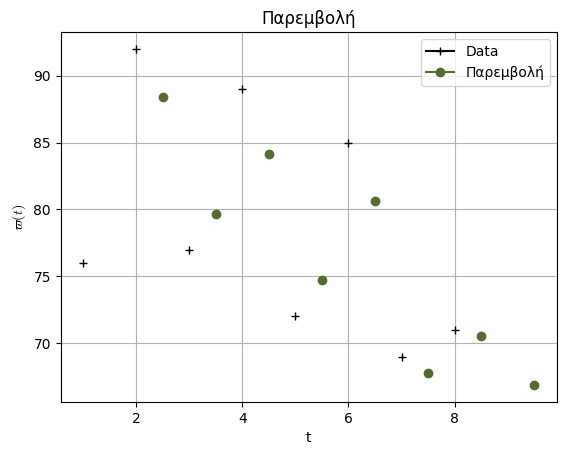

In [19]:
import numpy as np
import matplotlib.pyplot as plt
#Στο εργαστήριο φωτομετρίας, ο κ. Γαζέας μας παρέχει τα ακόλουθα δεδομένα για την ένταση μίας έκλαμψης ακτίνων γ συναρτήσει του χρόνου
t=[0.,1.,2.,3.,4.,5.,6.,7.,8.,9.,10.,11.,12.,13.,14.,15.,16.,17.,18.,19.,20.]
ϖ=[98.,76.,92.,77.,89.,72.,85.,69.,71.,69.,64.,57.,60.,52.,55.,47.,42.,35.,27.,23.]
#Και μας λέει ότι είναι πολύ σημαντικό για αυτόν να ξέρουμε την ένταση τις στιγμές 2.5, 3.5, κλπ, μέχρι 9.5:
T=[1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5]         #Το 1.5 δε μας το ζήτησε αλλά χρειάζεται
#Ας μην τον απογοητεύσουμε λοιπόν:
Π=np.zeros(8)
L0=0;L1=0;L2=0;                                 #Αρχικοποίηση
plt.figure()
for i in range (1,9):
  L0=((T[i]-t[i+1])*(T[i]-t[i+2]))/((t[i]-t[i+1])*(t[i]-t[i+2]))
  L1=((T[i]-t[i])*(T[i]-t[i+2]))/(-(t[i]-t[i+1])*(t[i+1]-t[i+2]))
  L2=((T[i]-t[i])*(T[i]-t[i+1]))/((t[i+2]-t[i])*(t[i+2]-t[i+1]))
  Π[i-1]=L0*ϖ[i]+L1*ϖ[i+1]+L2*ϖ[i+2]
  print('Η ένταση σε χρόνο ', T[i], 'είναι', Π[i-1])
  plt.plot(t[i],ϖ[i], color='k', marker='+')#Ας τα απεικονίσουμε, έχουν ένα ενδιαφέρον
  plt.plot(T[i], Π[i-1], color='darkolivegreen', marker='o')
plt.xlabel('t')
plt.ylabel('$ϖ(t)$')
plt.title('Παρεμβολή')
plt.grid(True)
plt.legend(['Data', 'Παρεμβολή'])
plt.show()
#Ευχαριστήθηκες, Γαζέα; Πονάς λιγότερο τώρα;

### **Παρεμβολή Newton**

Όταν επιθυμούμε να παρεμβάλλουμε σε **ισαπέχοντα** σημεία (έστω $h$ η απόστασή τους), όπως συνήθως συμβαίνει, η παρεμβολή Lagrange αποτελεί ελαφρώς "overkill". Πολύ απλούστερη αποδεικνύεται η μέθοδος Newton, η οποία όμως απαιτεί συνεχή προσοχή για την κατανόηση των διαφόρων συμβολισμών. Η **πεπερασμένη διαφορά προς τα εμπρός** (και η πεπερασμένη διαφορά τάξης $n$ προς τα εμπρός) ορίζονται ως

$$\Delta f_m=f(x_{m+1})-f(x_m)\equiv f_{m+1}-f_m\qquad\&\qquad \Delta^nf_m=\Delta^{n-1}f_{m+1}-\Delta^{n-1}f_m$$

αντίστοιχα. Η **πεπερασμένη διαφορά τάξης $n$ προς τα πίσω** ορίζεται ως:

$$\nabla^nf_m=\nabla^{n-1}f_{m}-\nabla^{n-1}f_{m-1}$$

Υπάρχουν τύποι-τέρατα για τις πεπερασμένες διαφορές $n$ τάξης. Προς τα εμπρός για παράδειγμα,

$$\Delta^nf_m=f(x+nh)+(-1)^1\begin{pmatrix}n \\ 1\end{pmatrix}f(x+(n-1)h)+...+(-1)^n\begin{pmatrix}n\\n\end{pmatrix}f(x),\qquad\begin{pmatrix}n\\k\end{pmatrix}=\frac{n!}{k!(n-k)!}$$

Επειδή, όπως και στην παρεμβολή Lagrange, σπανίως ζητείται ή είναι χρήσιμο ένα πολυώνυμο βαθμού $>2$, ίσως συμφέρει να καρτά κανείς σε σημείωση το

$$\Delta^2f_m=f_{m+2}-2f_{m+1}+f_m$$

Ας γίνουμε λίγο πιο πρακτικοί: έστω ότι γνωρίζουμε την τιμή μίας συνάρτησης σε σημείο $x_0$ και θέλουμε να την υπολογίσουμε στα σημεία $x_k=x_0kh$. Με έναν τελευταίο ορισμό,

$$\theta=(x-x_0)/h$$

*(εδώ υπονοείται πως το $x$ απέχει "ακέραιο" πλήθος βημάτων $h$ από το $x_0$, όμως υπάρχει γενίκευση- με συναρτήσεις $\Gamma$ κλπ.- και σε άλλη περίπτωση.)*

έχουμε

$$p_n(x)=f_0+\begin{pmatrix}\theta\\1\end{pmatrix}\Delta f_0+...+\begin{pmatrix}\theta\\ n\end{pmatrix}\Delta^nf_0$$

Ένας αλγόριθμος για πολυώνυμο $n$ βαθμού έχει επομένως την ακόλουθη μορφή:

*   Διάβασε τον $X=[x_0,...x_N]$ και τον $Y=[f(x_0), ... f(x_N)]$.
*   Διάβασε το $n$.
*   Διάβασε τον $\Xi$ *(ο πίνακας με τα σημεία στα οποία θέλουμε να παρεμβάλουμε)*. $\textrm{len}(\Xi)=\xi$.
*   Για κάθε $k$ από $1$ έως $\xi$ κάνε τα εξής:
    1. $p=Y[0]$.
    2. $\theta=(\Xi[k]-x)/h$.
    3. $\Delta f_0:= f_1-f_0$
    4. Για κάθε $\ell$ από $1$ έως $n$ κάνε τα εξής:
        1. $p+=\left(\Delta^{\ell-1}f_{1}-\Delta^{\ell-1}f_0\right)\cdot\textrm{fact}(\theta)/[\Delta^\ell f_0\textrm{fact}(k)\cdot\textrm{fact}(n-k)]$
    5. Τύπωσε $p$.

Ο παραπάνω αλγόριθμος είναι επίσης ελαφρώς "overkill". Ας γράψουμε τον αλγόριθμο για $n=2$ (πολυώνυμο 2ου βαθμού).

*   Διάβασε τα $X=[x_0,x_1,x_2]$, $Y=[f(x_0),f(x_1),f(x_2)]$, $\Xi=...$, $\textrm{len}(\Xi)=\xi$.
*   $\Delta f(a,b):=b-a$.
*   $\Delta^2 f(a,b,c):= c-2b+a$.
*   Για κάθε $k$ από $1$ έως $\xi$ κάνε τα εξής:
    1. $\theta=(\Xi[k]-x_0)/h$.
    2. $p=f(x_0)+\textrm{fact}(\theta)\Delta f(x_1, x_0)+\frac{\textrm{fact}(\theta)}{2\textrm{fact}(\theta-2)}\Delta^2f(x_2,x_1,x_0)$.
    3. Τύπωσε $p$.

[ 0.     4.125  1.5   -1.625 -4.5   -4.125 -1.5    1.625  4.5    4.125
  0.   ]


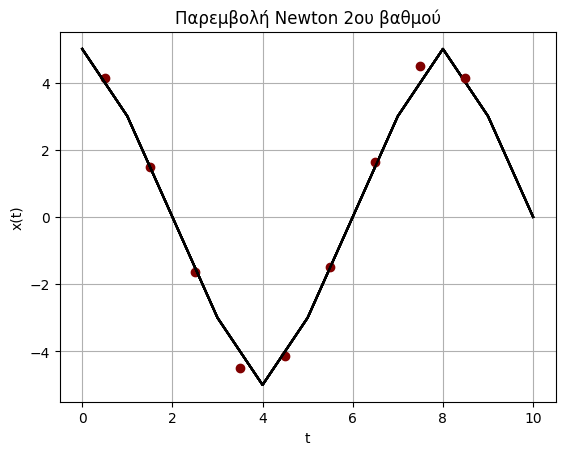

In [17]:
import numpy as np
import matplotlib.pyplot as plt
t=[0,1,2,3,4,5,6,7,8,9,10]
x=[5,3,0,-3,-5,-3,0,3,5,3,0]                    #Αρρρμονικός ταλαντωτής
T=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5]#Εδώ θέλουμε να παρεμβάλλουμε
h=T[1]-T[0]                                     #Σταθερό!
X=np.zeros(11)
plt.figure()
for i in range (len(T)-2):
  X[i+1]=x[i]+(x[i+1]-x[i])*(T[i]-t[i])/h+(x[i+2]-2*x[i+1]+x[i])*(T[i]-t[i])*(T[i]-t[i+1])/(2*h**2)
  plt.plot(t,x, color='black')                  #Οι 'κορυφές' είναι τα δοθέντα σημεία. Οι τεθλασμένες αποτελούν από μόνες τους τη γραμμική παρεμβολή!
  plt.plot(T[i],X[i+1], color='maroon',marker='o') #Η 'καλύτερη' παρεμβολή μας
plt.title('Παρεμβολή Newton 2ου βαθμού')
plt.grid('True')
plt.xlabel('t')
plt.ylabel('x(t)')
print(X)

## **6. Αριθμητική παραγώγιση**

Εδώ υπάρχει κατ' ουσίαν μόνο μία μέθοδος: θεωρητικά, προσεγγίζουμε τη συνάρτησή μας με ένα πολυώνυμο (π.χ. Newton) και το παραγωγίζουμε. Υπάρχει μόνο μία βασική προϋπόθεση:

> *Η τάξη παραγώγισης πρέπει να μην υπερβαίνει το βαθμό παρεμβολής*

δηλαδή

> ***Για να παραγωγίσουμε $\boldsymbol{\varpi}$ φορές χρειαζόμαστε πολυώνυμο τουλάχιστον $\boldsymbol{\varpi}$ βαθμού** (πρακτικά, καλό είναι το $\varpi+1$)*

Μας ενδιαφέρει αρχικά η παραγώγιση **3 σημείων** (για πολυώνυμο παρεμβολής 2ου βαθμού), η οποία είναι η απλούστερη δυνατή. Συγκεκριμένα, η παραγώγιση **μεσαίου σημείου (midpoint)** δίνεται από τον τύπο:

$$f'(x_0)\approx \frac{f(x_{1})-f(x_{-1})}{2h},$$

η παραγώγιση **2 σημείων, αρχικού** ή **τελικού** σημείου αντίστοιχα **(endpoint)** δίνεται από τους τύπους

$$f'(x_0)\approx \frac{f(x_1)-f(x_0)}{h},\qquad\qquad f'(x_0)\approx \frac{f(x_0)-f(x_{-1})}{h}.$$

Φυσικά, υπάρχουν τύποι για 3 point endpoint, 4 point midpoint κλπ. Απλώς είναι λίγο εκτενέστεροι.

Ένας ολοκληρωμένος αλγόριθμος που υπολογίζει την παράγωγο σε $N$ σημεία παρεμβολής είναι:

*   Διάβασε τους $X=[x_0,...x_N]$ και $Y=[f(x_0),...,f(x_N)]$. $h=X[1]-X[0]$.
*   $D=[\,]$. $D[0]=(Y[1]-Y[0])/h$.
*   Για κάθε $i$ από $1$ έως $N-1$ κάνε τα εξής:
    1. $D[i]=(Y[i+1]-Y[i-1])/2h$.
*   $D[N]=(Y[N]-Y[N-1])/h$.
*   Τύπωσε $D$.

In [21]:
import numpy as np
def f(x): f=np.cosh(x)+6.9; return f
x=[-2,-1,0,1,2]
y=[f(x[0]),f(x[1]),f(x[2]),f(x[3]), f(x[4])]                  #Τελικά δεν το χρησιμοποίησα για να είναι πιο ευανάγνωστος ο κώδιξ.
df=np.zeros(len(x))
#Θα μπορούσαμε σε όλα αυτά αντί για f(x[ϖ]) να γράφουμε y[ϖ]
df[0]=1/(x[1]-x[0])*(-3*f(x[0])/2+2*f(x[1])-1/2*f(x[2]))      #Παραγώγιση 3 σημείων endpoint

for i in range (1,len(x)-1):
  df[i]=1/(x[i]-x[i-1])*(f(x[i+1])/2-f(x[i-1])/2)             #Παραγώγιση 3 σημείων midpoint

df[-1]=1/(x[-1]-x[-2])*(3*f(x[-1])/2-2*f(x[-2])+1/2*f(x[-3])) #Παραγώγιση 3 σημείων endpoint, όπου με [-i] συμβολίζεται "το i-οστό από το τέλος"

print(y)
print(df)
#Ξέρουμε ότι d(coshx)/dx=sinh(x) και sinh(0)=0, άρα βγάζει νόημα!
#Επίσης, μας αρέσει που df[-ϖ]=-df[ϖ] επειδή το sinh είναι περιττή συνάρτηση. Ο κώδιξ δουλεύει!

[np.float64(10.662195691083632), np.float64(8.443080634815244), np.float64(7.9), np.float64(8.443080634815244), np.float64(10.662195691083632)]
[-3.05713227 -1.38109785  0.          1.38109785  3.05713227]


## **7. Αριθμητική ολοκλήρωση**

### **Κανόνας του τραπεζίου**
Εάν χωρίσουμε το διάστημα ολοκλήρωσης μιας συνάρτησης σε $N$ υποδιαστήματα ίδιου πάχους $h$ (δηλαδή, $h=(b-a)/N$), ισχύει
$$\int_a^b f(x)dx\approx h\left(\frac{f(x_0)+f(x_N)} {2}+\sum_{k=1}^{N-1}f(x_k)\right)$$

Ένας αλγόριθμος της μεθόδου του τραπεζίου λοιπόν θα έχει τη μορφή:
* Διάβασε το $N$, το $a$ και το $b$.
* $h=(b-a)/N$
* Διάβασε την $f(x)$.
* $I=h\cdot (f(a)+f(b))/2$.
* Για κάθε $k$ από το 1 έως το $N-1$ κάνε τα εξής:
   1. $I+=f(a+h)$
* Τύπωσε $I$.

In [11]:
N=2                                     #Μία σταθερά κανονικοποίησης, δε μας ενδιαφέρει
def f(x): f=N*np.exp(-x**2); return f   #Μία Γκαουσιανούλα
steps=500; a=-12; b=12;h=(b-a)/steps    #Τα άκρα του διαστήματος, ο αριθμός των βημάτων και ως αποτέλεσμα το βήμα
I=0                                     #Αρχικοποιούμε την τιμή του ολοκληρώματος
S=0;                                    #Απλώς αρχικοποιούμε έναν όρο που θα υπολογίσουμε μετά
for i in range (1, steps):
  S+=f(a+i*h)
S*=2
I=h/2*(f(a)+f(b)+S)
print(I)
#Ο Wolfram Alpha επιβεβαιώνει απόλυτα αυτό το αποτέλεσμα.

3.544907701811034


### **Μέθοδος Simpson**

Η μέθοδος του τραπεζίου στην ουσία περιγράφεται από το σκεπτικό ότι προσεγγίζουμε την ολοκληρωτέα συνάρτηση, τμηματικά, με πολυώνυμα 1ου βαθμού. Ο κανόνας του Simpson αποτελεί μία βελτίωση, αφού προσεγγίζει τη συνάρτηση με πολυώνυμα 2ου βαθμού. Ο "απλός" κανόνας του Simpson αποτελεί στην ουσία την προσέγγιση σε ένα βήμα:

$$ \int_a^bf(x)dx\approx \frac{b-a}{6}\left[f(a) +4f\left(\frac{a+b}{2}\right)+f(b)\right]$$

Ο "σύνθετος" κανόνας του Simpson αποτελεί τη γενίκευση της παραπάνω σχέσης με διαχωρισμό του διαστήματος σε $N$ υποδιαστήματα:

$$\int_a^bf(x)dx\approx \frac{h}{3}\left[f(x_0)+4\sum_{k=1}^{N/2}f(x_{2k-1})+2\sum_{k=1}^{N/2-1}f(x_{2k})+f(x_N)\right]$$

Ο αλγόριθμος της μεθόδου Simpson λοιπόν είναι ο εξής:

*   Διάβασε την $f(x)$, το $a$, το $b$ και το $N$. $h=(b-a)/N$.
*   $I=h(f(a)+f(b))/3$.
*   Για κάθε $k$ από $1$ έως $N/2$ κάνε τα εξής:
    1. $I+=4hf(a+(2k-1)h)/3$.
*   Για κάθε $\ell$ από $1$ έως $N/2-1$ κάνε τα εξής:
    1. $I+=2f(a+2kh)$.

Ο πολλ/σμός με $h/3$ μπορεί φυσικά να γίνει και σε ξεχωριστό βήμα στο τέλος.

In [14]:
D=0.69
def f(x): f=D*x**2*np.exp(-x**4); return f    #Μία πιο 'άγρια' γκαουσιανή
steps=100;a=-10;b=10;h=(b-a)/steps
I=0
for i in range(0, int(steps/2-1)+1):
  I+=f(a + 2*i*h) + 4*f(a + (2*i+1)*h) + f(a + 2*(i+1)*h)
I*=h/3
print(I)

0.42282771961639154


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4780/2154672776.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$σ/2\pi a^2$')


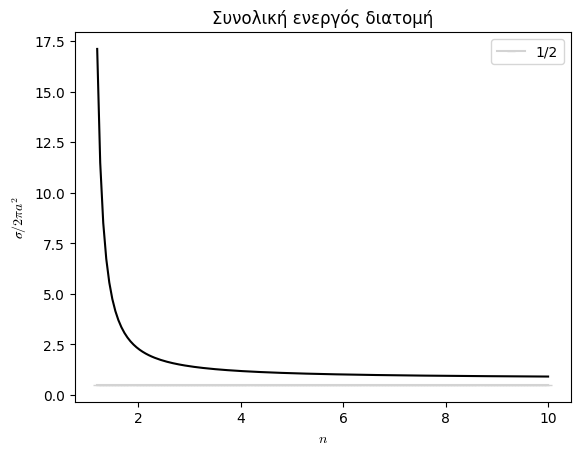

In [15]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['mathtext.fontset'] = 'cm'
N=np.linspace(1.2,10,150)
n=N[0]
def σ(x): return -x/((np.sin(np.asin(x/n)-np.asin(x)))*(np.cos(np.asin(x/n)-np.asin(x)))*((1/(np.sqrt(1-x**2))-1/(np.sqrt(n**2-x**2)))))
Σ=[]
a=0.1; b=0.9; steps=1001; h=(b-a)/steps; I=0
plt.figure()
for i in range (len(N)):
  n=N[i]
  for i in range(0, int(steps/2-1)+1):
   I+=σ(a + 2*i*h) + 4*σ(a + (2*i+1)*h) + σ(a + 2*(i+1)*h)
  I*=h/3
  Σ.append(I)
plt.plot(N, 1/2*N/N, marker='_', color='lightgray', label='1/2')
plt.plot(N, Σ, color='black')
plt.xlabel('$n$')
plt.ylabel('$σ/2\pi a^2$')
plt.title('Συνολική ενεργός διατομή')
plt.legend()
plt.show()

## **8. Συνήθεις Διαφορικές Εξισώσεις** ♥

### **Μέθοδος Euler**

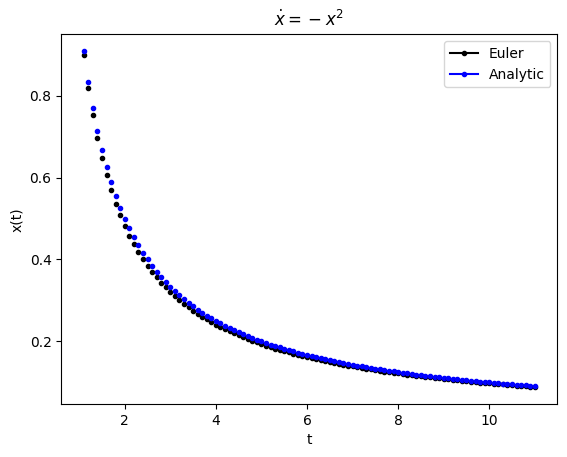

In [ ]:
import numpy as np
import matplotlib.pyplot as plt               #Για την αναπαράσταση μόνο

h=0.1                                         #Οτιδήποτε μικρό
steps=int(1000*h)                             #Όσο θέλουμε
x=1; t=1                                      #Αρχικές συνθήκες
def f(x): v=-x**2; return v                   #Ό,τι έχουμε κάθε φορά

plt.figure()
for i in range (steps):
  t+=h
  x+=h*f(x)
  y=1/t
  plt.plot(t, x, marker='.', color='black')
  plt.plot(t,y, marker='.', color='blue')     #Αναλυτική λύση για σύγκριση
  plt.xlabel('t')
  plt.ylabel('x(t)')
  plt.title('$\dot{x}=-x^2$')
  plt.legend(['Euler', 'Analytic'])
plt.show()
#Δοκιμάστε να βάλετε αρχικές συνθήκες t=0.5, έπειτα t=0.1 και τέλος t=0.0001. Τι παρατηρείτε;

### **ΣΔΕ ανώτερης τάξης (π.χ. 2ης, με Euler)**

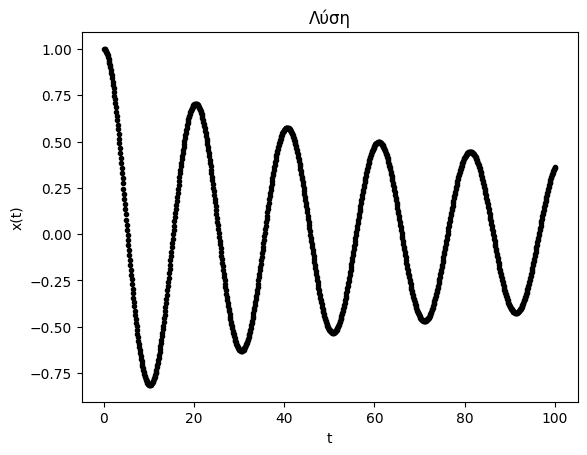

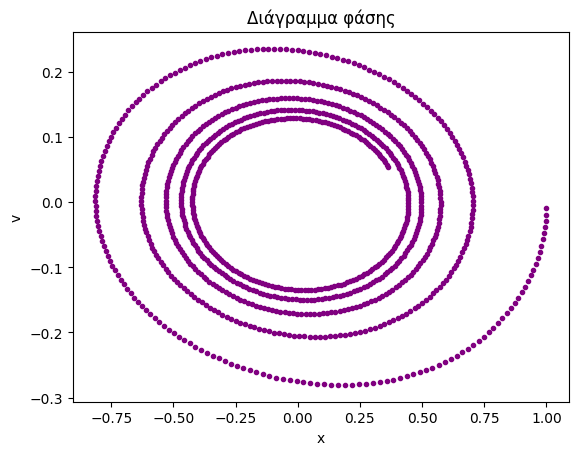

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
h=0.1
steps=int(10000*h)
solution=plt.figure(1)
x=1; v=0; t=0;w=0.31; gamma=0.69;
def a(x,v): a=-w**2*x-gamma*v**3; return a #Ταλαντωτής με μη γραμμική απόσβεση
for i in range (steps):
  t+=h
  x+=h*v                                  #'Σπάσαμε' τη 2τάξια σε 2 1τάξιες ΣΔΕ
  v+=h*a(x,v)
  plt.plot(t, x, marker='.', color='black')
  plt.xlabel('t')
  plt.ylabel('x(t)')
  plt.title('Λύση')
solution.show()
t=0; x=1; v=0
phase=plt.figure(2)
for i in range (steps):
  t+=h
  x+=h*v
  v+=h*a(x,v)
  plt.plot(x, v, marker='.', color='purple')
  plt.xlabel('x')
  plt.ylabel('v')
  plt.title('Διάγραμμα φάσης')
phase.show()
#Γενικά, κάθε ϖ-τάξια εξίσωση (που περιλαμβάνει παραγώγους, ας τις συμβολίζουμε d1x, d2x,... dϖx) μπορούμε πολύ εύκολα να τη σπάμε σε ϖ πρωτοτάξιες ως εξής:
#Η λ-οστή εξίσωση θα είναι dλx+=h*d(λ+1)x για κάθε λ<ϖ
#Και η ϖ-οστή εξίσωση θα είναι dϖx+=f(x,d1x,...,dϖx)

### **Μέθοδος Runge-Kutta 2ης τάξης (RK-2)**

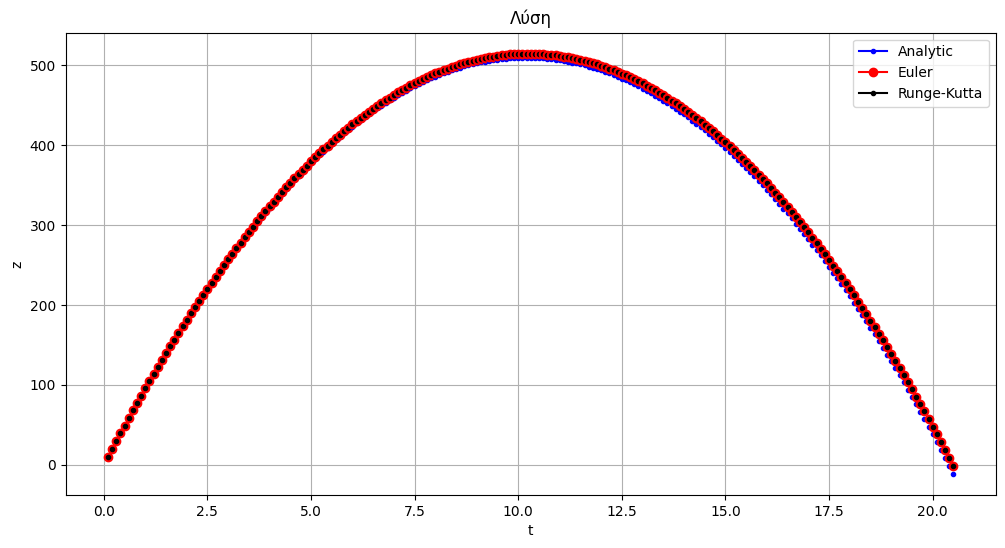

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h=0.1;
z=0; v=100; t=0; g=9.81;              #Αρχικές συνθήκες
e=0;de=100                            #Θα κάνουμε και Euler για σύγκριση
def f(t, x): f=-g; return f           #Ελεύθερη πτώση

def rk2(f, t, x, h):
  k1 = h * f(t, x)
  k2 = h * f(t + h, x + k1)
  return k1, k2
plt.figure(figsize=(12,6))
while(z>=0):
  z+=h*v
  v+=rk2(f, t, v, h)[0]/2+rk2(f, t, v, h)[1]/2
  t+=h
  e+=h*de
  de+=h*(-g)
  y=-g*t**2/2+100*t

  plt.plot(t,y, marker='.', color='blue')
  plt.plot(t, e, marker='o', color='red')
  plt.plot(t, z, marker='.', color='black')

plt.xlabel('t')
plt.ylabel('z')
plt.title('Λύση')
plt.legend([ 'Analytic', 'Euler','Runge-Kutta'])
plt.grid(True)
plt.show()
#Στο συγκεκριμένο πρόβλημα τυχαίνει (;) η Euler με τη Runge Kutta να ταυτίζονται!
#Αν προσθέσουμε (κάντε το) έναν όρο αντίστασης αέρα, π.χ. η*v**2, με η=10**(-3), θα αρχίσουμε να βλέπουμε διαφορά...

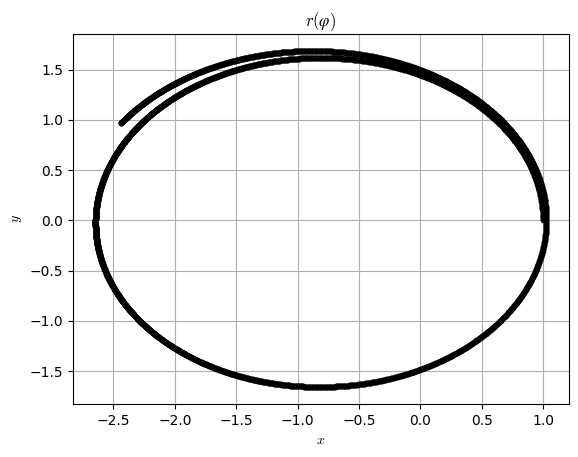

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['mathtext.fontset'] = 'cm'

delta=0.005; N=4300; m=1
def F(x,y): return 1/(x**2+y**2)

t=0;r=np.array([1.0,.0]);v=np.array([.0,1.2])
plt.figure()

for i in range (N):
  t+=delta

  R = np.sqrt(r[0]**2 + r[1]**2)

  Fx = -F(r[0],r[1]) * r[0] / R
  Fy = -F(r[0],r[1]) * r[1] / R

  for j in range (len(r)):
    r[j]+=delta*v[j]
  v[0]+=delta*Fx/m
  v[1]+=delta*Fy/m
  plt.plot(r[0],r[1], marker='.', color='black')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$r (φ)$')
plt.grid(True)
plt.show()

**Μηχανική: θέμα 2- 1-2023**

Μπορεί να αποδειχθεί (Ανάλυση Ι) ότι, αν $A\supseteq B\neq \emptyset$, $max(A)\geq max(B) \;\;\&\;\; min(B)\geq min(A) $. Στο παρακάτω πρόγραμμα γίνεται μία οπτική αναπαράσταση με τυχαίους αριθμούς.

**Ερωτήσεις:**


*   Γιατί και οι δύο καμπύλες στασιμοποιούνται; Σε ποιες τιμές στασιμοποιούνται;
*   Θα μπορούσαν να στασιμοποιηθούν ταυτόχρονα;
*   Έστω ένα τρίτο σύνολο $Γ$ με $A\supseteq Γ\supseteq B$. Πώς θα έμοιαζαν οι γραφικές παραστάσεις των $max(Γ), \; min(Γ)$;



<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\;'
<>:23: SyntaxWarning: invalid escape sequence '\;'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\;'
<>:23: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_13023/2958819632.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(count, M, color='red', label='$\mathcal{Max}$') #Αναμένουμε λοιπόν μία αύξουσα συνάρτηση εδώ
/tmp/ipykernel_13023/2958819632.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(count, m, color='blue', label='$\mathcal{Min}$')#Και μία φθίνουσα εδώ
/tmp/ipykernel_13023/2958819632.py:22: SyntaxWarning: invalid escape sequence '\;'
  plt.xlabel('$Πλήθος\; στοιχείων$')
/tmp/ipykernel_13023/2958819632.py:23: SyntaxWarning: invalid escape sequence '\;'
  plt.ylabel('$Max, \;min$')


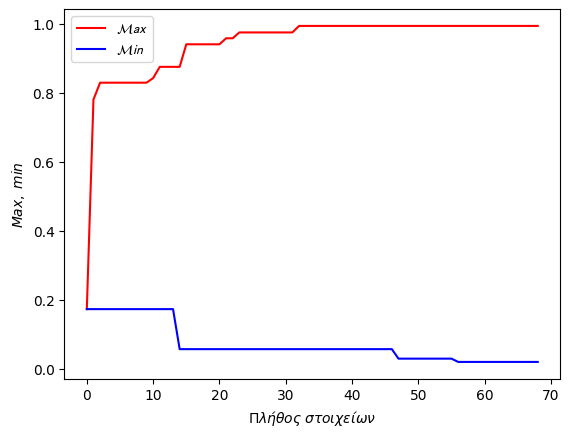

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N=69
count=[]
M=[]
m=[]
for i in range(N):
  a = np.random.rand()
  count.append(i)

  if i == 0:  #Ξεκινάμε τα max και min από την αρχική τιμή
    M.append(a)
    m.append(a)
  else:
    M.append(max(M[-1], a))  # To max μας είναι το max του νέου συνόλου, το οποίο να αναμένουμε να είναι >= του προηγούμενου
    m.append(min(m[-1], a))  # Ομοίως αναμένουμε το νέο min να είναι =< του προηγούμενου.

plt.figure()
plt.plot(count, M, color='red', label='$\mathcal{Max}$') #Αναμένουμε λοιπόν μία αύξουσα συνάρτηση εδώ
plt.plot(count, m, color='blue', label='$\mathcal{Min}$')#Και μία φθίνουσα εδώ
plt.xlabel('$Πλήθος\; στοιχείων$')
plt.ylabel('$Max, \;min$')
plt.legend()
plt.show()

Θα λύσουμε αριθμητικά την άσκηση 2 της 2ης εργασίας της Μηχανικής Ι για το ακαδ.έτος 2024-25. Ζητείται η επίλυση του προβλήματος:
$$\ddot{x}=\begin{cases} 2kx^2,\; x\geq0
\\ \frac{1}{2}kx^2,\; x<0
\end{cases}$$

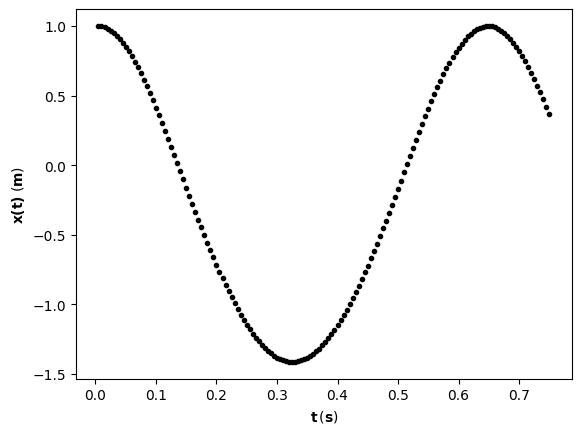

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def ap(t, x): ap=(-2)*k*x; return ap
def an(t, x): an=(-1)*k*x; return an

k=69
N=150
G=0.005

t=0;x=1;v=0.01

plt.figure()
for i in range (N):
 t=t+G
 if x>0 or x==0:
   x=x+G*v
   v=v+G*ap(t, x)
   plt.plot(t,x,marker='.', color='black')
 else:
   x =x+G*v
   v=v+G*an(t, x)
   plt.plot(t,x,marker='.', color='black')
plt.xlabel('$\mathbf{t}\, (\mathbf{s})$')
plt.ylabel('$\mathbf{x (t)}\; (\mathbf{m})$')
plt.show()